In [1]:
%pip install pandas numpy scikit-learn transformers torch sentence-transformers matplotlib

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import pipeline
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Change this path if necessary
df = pd.read_csv("/Users/yume/PycharmProjects/PBL2/data/reddit_dr.csv")

print(df.shape)
print(df.columns)

(12854, 9)
Index(['Title', 'Political Lean', 'Score', 'Id', 'Subreddit', 'URL',
       'Num of Comments', 'Text', 'Date Created'],
      dtype='object')


In [6]:
df["Title"] = df["Title"].fillna("").astype(str).str.strip()
df["Text"] = df["Text"].fillna("").astype(str).str.strip()

df["Text"] = (
    df["Title"]
    + " "
    + df["Text"]
).str.strip()

df["Political Lean"] = (
    df["Political Lean"]
    .astype(str)
    .str.strip()
)

df = df[
    df["Political Lean"].isin(
        ["Conservative", "Liberal"]
    )
].copy()

df = df[
    df["Text"].str.len() > 0
].reset_index(drop=True)

## RoBERTa sentiment features

In [7]:
sentiment_model = pipeline(
    task="text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    top_k=None,
    device=-1
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 33306.54it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
texts = df["Text"].tolist()

sentiment_results = sentiment_model(
    texts,
    batch_size=16,
    truncation=True,
    max_length=512
)

In [9]:
sentiment_rows = []

for result in sentiment_results:
    score_dictionary = {
        item["label"].lower(): item["score"]
        for item in result
    }

    # Handle models that return LABEL_0, LABEL_1, LABEL_2
    if "label_0" in score_dictionary:
        negative_score = score_dictionary.get("label_0", 0.0)
        neutral_score = score_dictionary.get("label_1", 0.0)
        positive_score = score_dictionary.get("label_2", 0.0)
    else:
        negative_score = score_dictionary.get("negative", 0.0)
        neutral_score = score_dictionary.get("neutral", 0.0)
        positive_score = score_dictionary.get("positive", 0.0)

    sentiment_rows.append({
        "roberta_negative": negative_score,
        "roberta_neutral": neutral_score,
        "roberta_positive": positive_score
    })

sentiment_df = pd.DataFrame(sentiment_rows)

sentiment_df.head()

,roberta_negative,roberta_neutral,roberta_positive
0,0.022105,0.912309,0.065586
1,0.814664,0.176303,0.009034
2,0.728048,0.248122,0.023830
3,0.428638,0.552767,0.018595
4,0.330648,0.625799,0.043553


In [10]:
df[
    [
        "roberta_negative",
        "roberta_neutral",
        "roberta_positive"
    ]
] = sentiment_df[
    [
        "roberta_negative",
        "roberta_neutral",
        "roberta_positive"
    ]
]

##moral-foundation semantic features

In [11]:
moral_prototypes = {
    "care": (
        "This text emphasizes compassion, empathy, protection, "
        "care for others, reducing suffering, and preventing harm."
    ),

    "fairness": (
        "This text emphasizes justice, fairness, equality, "
        "equal treatment, rights, and opposition to cheating."
    ),

    "loyalty": (
        "This text emphasizes loyalty to one's group, patriotism, "
        "solidarity, community allegiance, and opposition to betrayal."
    ),

    "authority": (
        "This text emphasizes authority, hierarchy, law, social order, "
        "tradition, obedience, and respect for institutions."
    ),

    "purity": (
        "This text emphasizes purity, sanctity, moral cleanliness, "
        "decency, contamination, corruption, or degradation."
    ),

    "liberty": (
        "This text emphasizes freedom, autonomy, individual rights, "
        "personal choice, and resistance to oppression or coercion."
    )
}

In [12]:
semantic_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6491.17it/s]


In [13]:
moral_names = list(moral_prototypes.keys())
moral_descriptions = list(moral_prototypes.values())

moral_prototype_embeddings = semantic_model.encode(
    moral_descriptions,
    batch_size=16,
    normalize_embeddings=True,
    show_progress_bar=True
)

print(moral_prototype_embeddings.shape)

Batches: 100%|██████████| 1/1 [00:01<00:00,  1.98s/it]

(6, 384)


In [14]:
post_embeddings = semantic_model.encode(
    df["Text"].tolist(),
    batch_size=32,
    normalize_embeddings=True,
    show_progress_bar=True
)

print(post_embeddings.shape)

Batches: 100%|██████████| 76/76 [00:10<00:00,  7.16it/s]

(2428, 384)


In [15]:
moral_similarity_scores = (
    post_embeddings
    @ moral_prototype_embeddings.T
)

moral_df = pd.DataFrame(
    moral_similarity_scores,
    columns=[
        f"moral_{name}"
        for name in moral_names
    ]
)

moral_df.head()

/var/folders/1z/hv4_qzyn6556dk5hqb4k6tdh0000gn/T/ipykernel_15172/211583188.py:2: RuntimeWarning: divide by zero encountered in matmul
  post_embeddings
/var/folders/1z/hv4_qzyn6556dk5hqb4k6tdh0000gn/T/ipykernel_15172/211583188.py:2: RuntimeWarning: overflow encountered in matmul
  post_embeddings
/var/folders/1z/hv4_qzyn6556dk5hqb4k6tdh0000gn/T/ipykernel_15172/211583188.py:2: RuntimeWarning: invalid value encountered in matmul
  post_embeddings


,moral_care,moral_fairness,moral_loyalty,moral_authority,moral_purity,moral_liberty
0,0.008286,0.072012,0.113781,0.017323,0.019100,0.075828
1,0.074667,0.173593,0.115170,0.062132,0.085645,0.176269
2,0.001343,0.045787,0.055033,0.004094,-0.011158,0.023357
3,0.324686,0.395134,0.314811,0.312540,0.299728,0.463789
4,0.029556,0.121109,0.068447,0.062043,0.119596,0.041557


In [16]:
df[
    moral_df.columns
] = moral_df

In [17]:
moral_feature_names = [
    f"moral_{name}"
    for name in moral_names
]

df[moral_feature_names].describe()

,moral_care,moral_fairness,moral_loyalty,moral_authority,moral_purity,moral_liberty
count,2428.000000,2428.000000,2428.000000,2428.000000,2428.000000,2428.000000
mean,0.090590,0.121746,0.131805,0.092179,0.102418,0.151358
std,0.076893,0.081271,0.088352,0.088582,0.077524,0.092957
min,-0.137064,-0.105564,-0.132382,-0.158006,-0.099217,-0.124156
25%,0.037208,0.063696,0.070226,0.030874,0.047672,0.087571
50%,0.085107,0.117249,0.131444,0.086169,0.100839,0.148306
75%,0.139371,0.173130,0.193772,0.146375,0.154025,0.210040
max,0.447005,0.509494,0.424317,0.482073,0.357813,0.520689


In [18]:
df.to_csv(
    "reddit_with_semantic_features.csv",
    index=False
)

print("Saved enriched dataframe.")

Saved enriched dataframe.


In [19]:
sentiment_features = [
    "roberta_negative",
    "roberta_neutral",
    "roberta_positive"
]

moral_features = [
    "moral_care",
    "moral_fairness",
    "moral_loyalty",
    "moral_authority",
    "moral_purity",
    "moral_liberty"
]

semantic_features = (
    sentiment_features
    + moral_features
)

all_feature_columns = (
    ["Text"]
    + semantic_features
)

In [20]:
model_df = df.dropna(
    subset=[
        "Text",
        "Political Lean"
    ] + semantic_features
).copy()

In [21]:
X = model_df[all_feature_columns]
y = model_df["Political Lean"]

print(X.shape)
print(y.value_counts())

(2428, 10)
Political Lean
Liberal         1471
Conservative     957
Name: count, dtype: int64


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 1942
Test rows: 486


In [23]:
full_preprocessor = ColumnTransformer(
    transformers=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.95,
                sublinear_tf=True,
                max_features=50000
            ),
            "Text"
        ),

        (
            "semantic",
            StandardScaler(),
            semantic_features
        )
    ],
    remainder="drop"
)

In [24]:
full_pipeline = Pipeline([
    (
        "preprocessor",
        full_preprocessor
    ),

    (
        "classifier",
        LogisticRegression(
            solver="liblinear",
            penalty="l2",
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    )
])

In [25]:
full_param_grid = {
    "preprocessor__tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "preprocessor__tfidf__min_df": [
        2,
        3,
        5
    ],

    "preprocessor__tfidf__stop_words": [
        None,
        "english"
    ],

    "classifier__C": [
        0.1,
        0.5,
        1,
        2,
        5
    ]
}

In [26]:
full_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=full_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

full_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'classifier__C': [0.1, 0.5, ...], 'preprocessor__tfidf__min_df': [2, 3, ...], 'preprocessor__tfidf__ngram_range': [(1, ...), (1, ...)], 'preprocessor__tfidf__stop_words': [None, 'english']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('tfidf', ...), ('semantic', ...)]"


In [27]:
best_full_model = full_search.best_estimator_

full_predictions = best_full_model.predict(
    X_test
)

full_accuracy = accuracy_score(
    y_test,
    full_predictions
)

full_macro_f1 = f1_score(
    y_test,
    full_predictions,
    average="macro"
)

print("Best parameters:")
print(full_search.best_params_)

print("\nBest CV macro F1:")
print(full_search.best_score_)

print("\nTest accuracy:")
print(full_accuracy)

print("\nTest macro F1:")
print(full_macro_f1)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        full_predictions
    )
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_test,
        full_predictions
    )
)

Best parameters:
{'classifier__C': 2, 'preprocessor__tfidf__min_df': 5, 'preprocessor__tfidf__ngram_range': (1, 1), 'preprocessor__tfidf__stop_words': None}

Best CV macro F1:
0.7438127844263169

Test accuracy:
0.7530864197530864

Test macro F1:
0.7439095076669067

Classification report:
              precision    recall  f1-score   support

Conservative       0.68      0.71      0.70       192
     Liberal       0.81      0.78      0.79       294

    accuracy                           0.75       486
   macro avg       0.74      0.75      0.74       486
weighted avg       0.76      0.75      0.75       486


Confusion matrix:
[[137  55]
 [ 65 229]]


## TF-IDF only

In [28]:
tfidf_only_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_df=0.95,
            max_features=50000
        )
    ),

    (
        "classifier",
        LogisticRegression(
            solver="liblinear",
            penalty="l2",
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    )
])

In [29]:
tfidf_only_param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        2,
        3,
        5
    ],

    "tfidf__stop_words": [
        None,
        "english"
    ],

    "classifier__C": [
        0.1,
        0.5,
        1,
        2,
        5
    ]
}

In [30]:
tfidf_only_search = GridSearchCV(
    estimator=tfidf_only_pipeline,
    param_grid=tfidf_only_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

tfidf_only_search.fit(
    X_train["Text"],
    y_train
)

tfidf_only_predictions = tfidf_only_search.predict(
    X_test["Text"]
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


## roberta, moral w/o tfidf

In [31]:
semantic_only_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "classifier",
        LogisticRegression(
            solver="liblinear",
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    )
])

In [32]:
semantic_only_search = GridSearchCV(
    estimator=semantic_only_pipeline,
    param_grid={
        "classifier__C": [
            0.01,
            0.1,
            0.5,
            1,
            2,
            5,
            10
        ]
    },
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

semantic_only_search.fit(
    X_train[semantic_features],
    y_train
)

semantic_only_predictions = (
    semantic_only_search.predict(
        X_test[semantic_features]
    )
)

/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yume/Pychar

In [33]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF only",
        "RoBERTa + moral features only",
        "TF-IDF + RoBERTa + moral features"
    ],

    "Accuracy": [
        accuracy_score(
            y_test,
            tfidf_only_predictions
        ),

        accuracy_score(
            y_test,
            semantic_only_predictions
        ),

        accuracy_score(
            y_test,
            full_predictions
        )
    ],

    "Macro F1": [
        f1_score(
            y_test,
            tfidf_only_predictions,
            average="macro"
        ),

        f1_score(
            y_test,
            semantic_only_predictions,
            average="macro"
        ),

        f1_score(
            y_test,
            full_predictions,
            average="macro"
        )
    ],

    "Best CV Macro F1": [
        tfidf_only_search.best_score_,
        semantic_only_search.best_score_,
        full_search.best_score_
    ]
})

comparison

,Model,Accuracy,Macro F1,Best CV Macro F1
0,TF-IDF only,0.767490,0.759422,0.754438
1,RoBERTa + moral features only,0.596708,0.586045,0.590696
2,TF-IDF + RoBERTa + moral features,0.753086,0.743910,0.743813


In [34]:
full_classifier = (
    best_full_model
    .named_steps["classifier"]
)

print(full_classifier.classes_)

['Conservative' 'Liberal']


In [35]:
full_preprocessor_fitted = (
    best_full_model
    .named_steps["preprocessor"]
)

feature_names = (
    full_preprocessor_fitted
    .get_feature_names_out()
)

coefficients = full_classifier.coef_[0]

coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
})

In [36]:
semantic_coefficient_df = (
    coefficient_df[
        coefficient_df["feature"]
        .str.startswith("semantic__")
    ]
    .copy()
)

semantic_coefficient_df["feature"] = (
    semantic_coefficient_df["feature"]
    .str.replace(
        "semantic__",
        "",
        regex=False
    )
)

semantic_coefficient_df = (
    semantic_coefficient_df
    .sort_values(
        "coefficient",
        ascending=False
    )
)

semantic_coefficient_df

,feature,coefficient,absolute_coefficient
5312,moral_care,0.349245,0.349245
5314,moral_loyalty,0.302959,0.302959
5310,roberta_neutral,0.058113,0.058113
5311,roberta_positive,0.040829,0.040829
5313,moral_fairness,0.007141,0.007141
5315,moral_authority,0.006724,0.006724
5309,roberta_negative,-0.074843,0.074843
5316,moral_purity,-0.320378,0.320378
5317,moral_liberty,-0.424822,0.424822


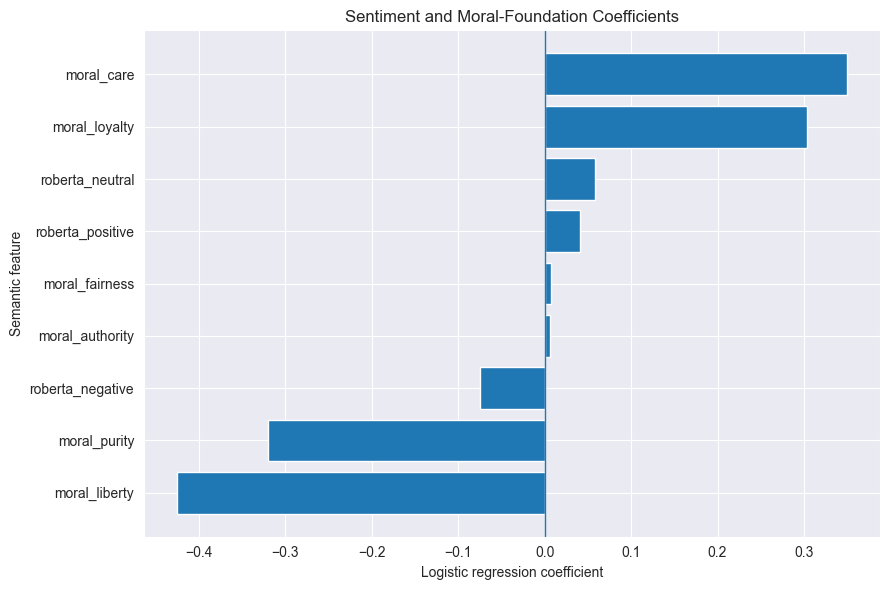

In [37]:
plot_df = semantic_coefficient_df.sort_values(
    "coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Logistic regression coefficient")
plt.ylabel("Semantic feature")
plt.title(
    "Sentiment and Moral-Foundation Coefficients"
)

plt.tight_layout()
plt.show()

In [38]:
semantic_group_summary = (
    model_df
    .groupby("Political Lean")[
        semantic_features
    ]
    .mean()
    .T
)

semantic_group_summary


Political Lean,Conservative,Liberal
roberta_negative,0.398782,0.322381
roberta_neutral,0.505944,0.543655
roberta_positive,0.095273,0.133964
moral_care,0.086064,0.093534
moral_fairness,0.126966,0.118350
moral_loyalty,0.126367,0.135342
moral_authority,0.097255,0.088877
moral_purity,0.111115,0.096761
moral_liberty,0.156982,0.147700


In [39]:
semantic_group_summary["Liberal_minus_Conservative"] = (
    semantic_group_summary["Liberal"]
    - semantic_group_summary["Conservative"]
)

semantic_group_summary.sort_values(
    "Liberal_minus_Conservative",
    ascending=False
)

Political Lean,Conservative,Liberal,Liberal_minus_Conservative
roberta_positive,0.095273,0.133964,0.038691
roberta_neutral,0.505944,0.543655,0.037711
moral_loyalty,0.126367,0.135342,0.008975
moral_care,0.086064,0.093534,0.007471
moral_authority,0.097255,0.088877,-0.008378
moral_fairness,0.126966,0.118350,-0.008616
moral_liberty,0.156982,0.147700,-0.009282
moral_purity,0.111115,0.096761,-0.014354
roberta_negative,0.398782,0.322381,-0.076402


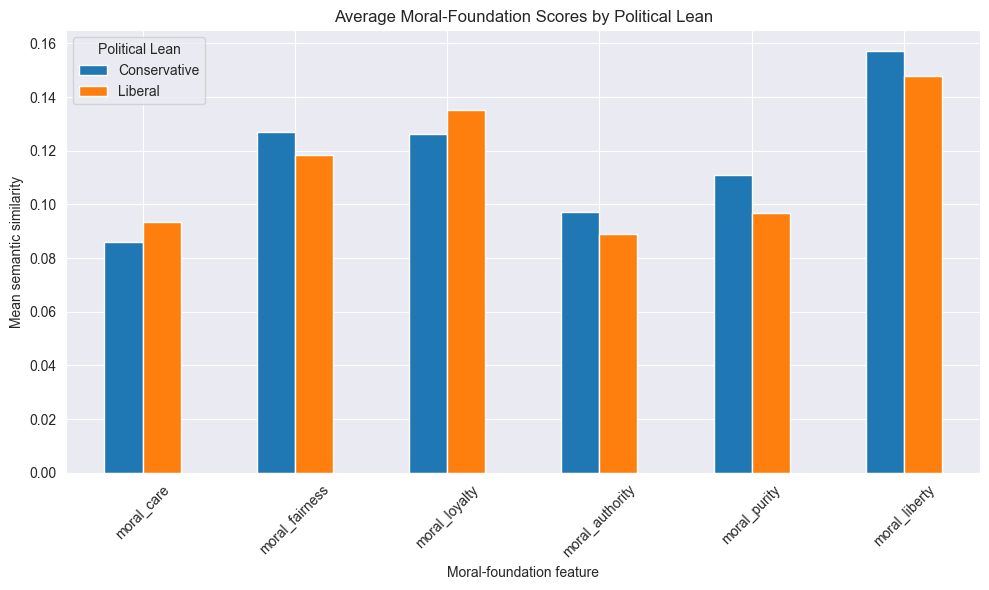

In [40]:
moral_group_means = (
    model_df
    .groupby("Political Lean")[
        moral_features
    ]
    .mean()
    .T
)

moral_group_means.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Mean semantic similarity")
plt.xlabel("Moral-foundation feature")
plt.title(
    "Average Moral-Foundation Scores by Political Lean"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
df

,Title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,Text,Date Created,roberta_negative,roberta_neutral,roberta_positive,moral_care,moral_fairness,moral_loyalty,moral_authority,moral_purity,moral_liberty
0,State of the union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,State of the union Who watched the state of th...,1.646270e+09,0.022105,0.912309,0.065586,0.008286,0.072012,0.113781,0.017323,0.019100,0.075828
1,Be careful when you post to r/politics and r/a...,Liberal,4,t5dyno,democrats,https://www.reddit.com/r/democrats/comments/t5...,3,Be careful when you post to r/politics and r/a...,1.646266e+09,0.814664,0.176303,0.009034,0.074667,0.173593,0.115170,0.062132,0.085645,0.176269
2,Money money money,Liberal,3,t5c22l,socialism,https://www.reddit.com/r/socialism/comments/t5...,1,Money money money One of the things I have not...,1.646260e+09,0.728048,0.248122,0.023830,0.001343,0.045787,0.055033,0.004094,-0.011158,0.023357
3,Between Gilead and OnlyFans: Notes on the Oppr...,Liberal,9,t58yxa,socialism,https://www.reddit.com/r/socialism/comments/t5...,0,Between Gilead and OnlyFans: Notes on the Oppr...,1.646252e+09,0.428638,0.552767,0.018595,0.324686,0.395134,0.314811,0.312540,0.299728,0.463789
4,Ax tax or sledgehammer tax; a term I've been h...,Liberal,2,t53lzx,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,Ax tax or sledgehammer tax; a term I've been h...,1.646238e+09,0.330648,0.625799,0.043553,0.029556,0.121109,0.068447,0.062043,0.119596,0.041557
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2423,Excerpt from Brave New World,Conservative,3,zzy6t,anarchocapitalism,https://www.reddit.com/r/anarchocapitalism/com...,3,"Excerpt from Brave New World ""Well now, which ...",1.347843e+09,0.286357,0.668393,0.045250,0.184483,0.106305,0.048735,0.159033,0.224401,0.174700
2424,How would restitution be enforced in an ancap ...,Conservative,3,yw78n,anarchocapitalism,https://www.reddit.com/r/anarchocapitalism/com...,4,How would restitution be enforced in an ancap ...,1.346052e+09,0.477878,0.509311,0.012811,0.100330,0.219740,0.069775,0.203758,0.128603,0.166933
2425,What does AnCap think about collective bargain...,Conservative,4,ysknt,anarchocapitalism,https://www.reddit.com/r/anarchocapitalism/com...,1,What does AnCap think about collective bargain...,1.345869e+09,0.034990,0.773516,0.191494,0.051726,0.204310,0.160086,0.169551,0.057985,0.192923
2426,Questions about The School Sucks Podcast,Conservative,6,raawy,anarchocapitalism,https://www.reddit.com/r/anarchocapitalism/com...,3,Questions about The School Sucks Podcast Last ...,1.332527e+09,0.581951,0.376945,0.041104,0.116401,0.082768,0.195254,0.125327,0.054566,0.197231


In [43]:
df.describe()

,Score,Num of Comments,Date Created,roberta_negative,roberta_neutral,roberta_positive,moral_care,moral_fairness,moral_loyalty,moral_authority,moral_purity,moral_liberty
count,2428.000000,2428.000000,2.428000e+03,2428.000000,2428.000000,2428.000000,2428.000000,2428.000000,2428.000000,2428.000000,2428.000000,2428.000000
mean,49.289539,36.214992,1.623249e+09,0.352495,0.528791,0.118714,0.090590,0.121746,0.131805,0.092179,0.102418,0.151358
std,527.901281,100.106897,5.534916e+07,0.289963,0.246651,0.187984,0.076893,0.081271,0.088352,0.088582,0.077524,0.092957
min,0.000000,0.000000,1.266602e+09,0.001571,0.008765,0.004484,-0.137064,-0.105564,-0.132382,-0.158006,-0.099217,-0.124156
25%,2.000000,4.000000,1.635962e+09,0.073300,0.323334,0.019210,0.037208,0.063696,0.070226,0.030874,0.047672,0.087571
50%,7.000000,12.000000,1.641656e+09,0.295753,0.550189,0.043271,0.085107,0.117249,0.131444,0.086169,0.100839,0.148306
75%,24.000000,32.000000,1.644926e+09,0.600208,0.745290,0.112836,0.139371,0.173130,0.193772,0.146375,0.154025,0.210040
max,25055.000000,2150.000000,1.646270e+09,0.964650,0.953429,0.987935,0.447005,0.509494,0.424317,0.482073,0.357813,0.520689


array([[<Axes: title={'center': 'Score'}>,
        <Axes: title={'center': 'Num of Comments'}>,
        <Axes: title={'center': 'Date Created'}>],
       [<Axes: title={'center': 'roberta_negative'}>,
        <Axes: title={'center': 'roberta_neutral'}>,
        <Axes: title={'center': 'roberta_positive'}>],
       [<Axes: title={'center': 'moral_care'}>,
        <Axes: title={'center': 'moral_fairness'}>,
        <Axes: title={'center': 'moral_loyalty'}>],
       [<Axes: title={'center': 'moral_authority'}>,
        <Axes: title={'center': 'moral_purity'}>,
        <Axes: title={'center': 'moral_liberty'}>]], dtype=object)

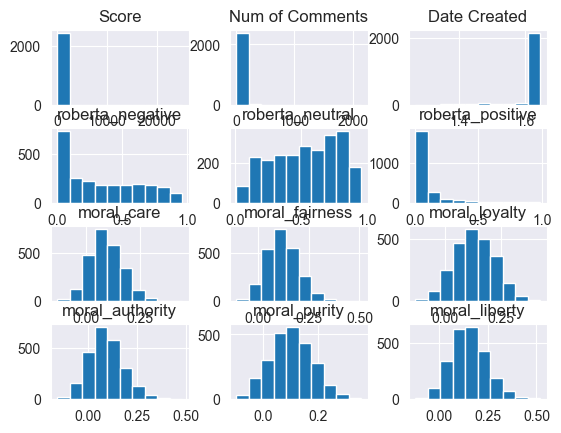

In [44]:
df.hist()

<Axes: >

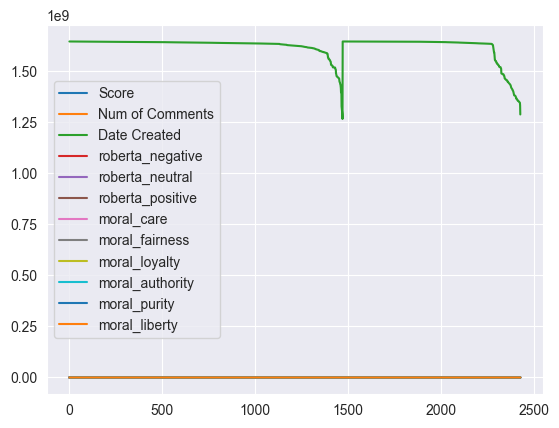

In [45]:
df.plot()